# IEMOCAP MER Benchmark — 4-class, LOSO 5-fold (Audio + Facial Expression)

Research-grade benchmark of the proposed cascade against three competitors on
**IEMOCAP**, under the standard 4-class / LOSO protocol. Text is not used.

## Protocol
- **Classes (4):** `neutral, happy, sad, angry`. `excited → happy`; all other
  emotions (`frustrated, fear, surprise, disgust, oth, xxx`) discarded.
- **Split:** official 5-fold **Leave-One-Session-Out** — each session is the
  test fold once; the next session (cyclic) is validation; the remaining three
  train. Final score = mean ± std over the 5 folds.
- **Metrics:** Weighted Accuracy (WA), Unweighted Accuracy (UA / UAR — main),
  Macro-F1, per-class F1, confusion matrix.

## Face selection — gender-letter heuristic
IEMOCAP `dialog/avi/DivX/*.avi` shows both actors side-by-side. The target
speaker's half-frame is chosen from the **speaker letter** in the utterance id
(`Ses01F_impro01_F000 → F → female track`): the script-leader sits on the left,
so the side is `L` when the utterance speaker letter equals the dialogue-leader
letter, else `R`. Face detection (MediaPipe BlazeFace) then runs on that half.

## Models benchmarked (the same models, all under identical conditions)
| Model | Modalities | Notes |
|---|---|---|
| Ours — MelCNN→BiLSTM | audio + video (cascade) | binary audio gate → BiLSTM video head |
| Ours — MelCNN→BiGRU  | audio + video (cascade) | same gate → BiGRU video head |
| SCME+GF              | audio + video | transformer + cross-attn + gated fusion |
| MM-NodeFormer        | audio + video | two-stream cross-modal transformer |
| ResNet18+GRU         | video         | ResNet18 frame features → BiGRU |

Every model is trained per fold with one shared trainer (same folds, loss,
optimizer schedule, early stopping) on the shared feature cache.

## Pipeline stages
1. Dataset indexing → `metadata/iemocap_4class.csv`
2/3. Video + audio preprocessing → feature cache (gender-letter faces)
4. PyTorch dataset · 5. Model interface · 6. Trainer · 7. Evaluation
8. Reproducibility · 9. Experiment tracking · 10. Final benchmark table

## 1. Configuration & reproducibility (Stages 8)

Single config dict (replaces `configs/*.yaml`; the project is notebook-based, so
Hydra/OmegaConf are intentionally not used). All paths are relative — no
hardcoded absolutes. Seeds, deterministic algorithms and the git hash are fixed
and logged for reproducibility.

In [1]:
import os, re, json, gc, time, math, pickle, random, warnings, subprocess, platform
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

# --- reproducibility (Stage 8) -----------------------------------------
SEED = 42
def seed_everything(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything()

device = torch.device("cuda" if torch.cuda.is_available()
                       else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:", device)

# --- paths (run from notebooks/ or repo root — both work) --------------
ROOT = Path.cwd()
if not (ROOT / "datasets").exists() and (ROOT / ".." / "datasets").exists():
    ROOT = (ROOT / "..").resolve()
IEMOCAP_ROOT   = ROOT / "datasets" / "IEMOCAP_full_release"
FEAT_CACHE     = ROOT / "datasets" / "iemocap_features_cache"   # gender-letter faces
AUDIO_CKPT_DIR = ROOT / "trained_models" / "audio_neutral_3_augmentation"
VIDEO_CKPT_DIR = ROOT / "trained_models" / "video_emotion_3_augmentation"
FACE_DETECTOR  = ROOT / "raw_models" / "blaze_face_short_range.tflite"
META_DIR    = ROOT / "metadata"
RESULTS_DIR = ROOT / "results"
OUT_DIR     = ROOT / "trained_models" / "iemocap_benchmark_4class"
CKPT_DIR    = OUT_DIR / "checkpoints"
LOG_DIR     = OUT_DIR / "logs"
for d in (META_DIR, RESULTS_DIR, OUT_DIR, CKPT_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- task: 4-class IEMOCAP ---------------------------------------------
LABELS_4 = ["neutral", "happy", "sad", "angry"]
RAW2IDX  = {"neu": 0, "hap": 1, "exc": 1, "sad": 2, "ang": 3}   # exc -> hap
N_CLS    = len(LABELS_4)

# --- feature dimensions (precomputed cache) ----------------------------
FEAT_EFF, FEAT_RES, FEAT_W2V = 1280, 512, 768
N_FRAMES, N_MELS, MEL_LEN    = 16, 64, 128

# --- audio-gate log-mel normalization (from pretrained MelCNN meta) ----
_amETA   = json.load(open(AUDIO_CKPT_DIR / "meta.json"))
SR, HOP  = _amETA["SR"], _amETA["HOP"]
MEL_MEAN, MEL_STD = _amETA["mel_mean"], _amETA["mel_std"]

# --- LOSO: each session test once; next session (cyclic) = validation --
SESSIONS = [f"Session{i}" for i in range(1, 6)]
LOSO_VAL_FOR_TEST = {s: SESSIONS[(i + 1) % 5] for i, s in enumerate(SESSIONS)}

# --- training config (was configs/model_x.yaml in the spec) ------------
TRAIN_CFG = dict(
    epochs=40, patience=8, batch_size=16,
    lr=1e-3,           # competitors trained from scratch
    lr_finetune=3e-4,  # our pretrained-initialised heads
    weight_decay=1e-4, label_smoothing=0.1, grad_clip=1.0,
    accum_steps=1,     # gradient accumulation (Stage 6)
    num_workers=0,     # macOS/MPS: 0 is safest
    augment=False, aug_noise=0.05,   # optional train-only feature-space aug
)
QUICK_TEST = os.environ.get("BENCH_QUICK", "0") == "1"  # fast 2-epoch smoke run
if QUICK_TEST:
    TRAIN_CFG["epochs"], TRAIN_CFG["patience"] = 2, 2

EPOCHS      = TRAIN_CFG["epochs"];      PATIENCE    = TRAIN_CFG["patience"]
BS          = TRAIN_CFG["batch_size"];  WD          = TRAIN_CFG["weight_decay"]
LR_SCRATCH  = TRAIN_CFG["lr"];          LR_FINETUNE = TRAIN_CFG["lr_finetune"]
LABEL_SMOOTH= TRAIN_CFG["label_smoothing"]; GRAD_CLIP = TRAIN_CFG["grad_clip"]
NUM_WORKERS = TRAIN_CFG["num_workers"]; ACCUM       = TRAIN_CFG["accum_steps"]

def git_hash():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=str(ROOT),
                                       stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return "unknown"

def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

print("git", git_hash()[:10], "| QUICK_TEST", QUICK_TEST, "| epochs", EPOCHS)
print("config:", TRAIN_CFG)

Device: mps
git fee2a24664 | QUICK_TEST False | epochs 40
config: {'epochs': 40, 'patience': 8, 'batch_size': 16, 'lr': 0.001, 'lr_finetune': 0.0003, 'weight_decay': 0.0001, 'label_smoothing': 0.1, 'grad_clip': 1.0, 'accum_steps': 1, 'num_workers': 0, 'augment': False, 'aug_noise': 0.05}


## 2. Stage 1 — Dataset indexing

Traverse all 5 IEMOCAP sessions, parse `dialog/EmoEvaluation/*.txt` (emotion +
utterance id + timestamps) and `dialog/transcriptions/*.txt` (text). Keep the 4
benchmark classes (`exc → hap`), collect wav / video paths and speaker id, and
write `metadata/iemocap_4class.csv`.

In [2]:
EMO_LINE_RE = re.compile(r"^\[\s*([\d.]+)\s*-\s*([\d.]+)\s*\]\s+(\S+)\s+(\w+)\s+\[")
TRANS_RE    = re.compile(r"^(\S+)\s+\[[^\]]*\]\s*:\s*(.*)$")

def parse_emoeval(path, session):
    rows = []
    for line in open(path, encoding="utf-8", errors="ignore"):
        m = EMO_LINE_RE.match(line)
        if m:
            start, end, utt, emo = m.groups()
            rows.append(dict(session=session, utt_id=utt, start=float(start),
                             end=float(end), emotion_raw=emo))
    return rows

def parse_transcripts(path):
    d = {}
    for line in open(path, encoding="utf-8", errors="ignore"):
        m = TRANS_RE.match(line.strip())
        if m:
            d[m.group(1)] = m.group(2).strip()
    return d

records, transcripts = [], {}
for s in range(1, 6):
    sess = f"Session{s}"
    emo_dir = IEMOCAP_ROOT / sess / "dialog" / "EmoEvaluation"
    trn_dir = IEMOCAP_ROOT / sess / "dialog" / "transcriptions"
    for txt in sorted(emo_dir.glob("*.txt")):
        if not txt.name.startswith("."):
            records.extend(parse_emoeval(txt, sess))
    for txt in sorted(trn_dir.glob("*.txt")):
        if not txt.name.startswith("."):
            transcripts.update(parse_transcripts(txt))

meta = (pd.DataFrame.from_records(records)
          .drop_duplicates("utt_id").reset_index(drop=True))
print(f"raw utterances from EmoEvaluation: {len(meta)}")
print("emotion counts (pre-filter):", meta.emotion_raw.value_counts().to_dict())

# --- keep the 4 benchmark classes (exc -> hap) -------------------------
meta = meta[meta.emotion_raw.isin(RAW2IDX)].reset_index(drop=True)
meta["label"]   = meta.emotion_raw.map(RAW2IDX)
meta["emotion"] = meta.label.map(dict(enumerate(LABELS_4)))
meta["dialog"]  = meta.utt_id.str.rsplit("_", n=1).str[0]
# speaker id: session + utterance-speaker gender letter (Ses01F_..._F000 -> Session1_F)
meta["speaker"] = meta.apply(
    lambda r: f"{r.session}_{r.utt_id.split('_')[-1][0]}", axis=1)
meta["wav_path"] = meta.apply(
    lambda r: str(IEMOCAP_ROOT / r.session / "sentences" / "wav"
                  / r.dialog / f"{r.utt_id}.wav"), axis=1)
meta["video_path"] = meta.apply(
    lambda r: str(IEMOCAP_ROOT / r.session / "dialog" / "avi" / "DivX"
                  / f"{r.dialog}.avi"), axis=1)
meta["transcript"] = meta.utt_id.map(transcripts).fillna("")

csv_cols = ["utt_id", "session", "speaker", "label", "emotion",
            "start", "end", "wav_path", "video_path", "transcript"]
meta[csv_cols].to_csv(META_DIR / "iemocap_4class.csv", index=False)
print(f"\n4-class utterances: {len(meta)}  ->  {META_DIR / 'iemocap_4class.csv'}")
print(meta.groupby(["session", "emotion"]).size().unstack(fill_value=0))

raw utterances from EmoEvaluation: 10039
emotion counts (pre-filter): {'xxx': 2507, 'fru': 1849, 'neu': 1708, 'ang': 1103, 'sad': 1084, 'exc': 1041, 'hap': 595, 'sur': 107, 'fea': 40, 'oth': 3, 'dis': 2}

4-class utterances: 5531  ->  /Users/kaparya/Desktop/Diploma/metadata/iemocap_4class.csv
emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 3. Stage 2 & 3 — Video / audio preprocessing → feature cache

Per-utterance features are cached at `datasets/iemocap_features_cache/{utt}.pt`
(`video_eff` 16×1280 EmotiEffNet · `video_res` 16×512 ResNet18 · `audio_w2v`
16×768 Wav2Vec2 · `audio_mel` 64×128 log-mel).

**Video.** 16 frames uniformly sampled per utterance; the target speaker's
half-frame is picked by the **gender-letter heuristic** (`speaker_side`); face
detected with MediaPipe BlazeFace (centre-crop fallback on a miss); 224×224 crop
→ EmotiEffNet + ResNet18 features. **Audio.** Resampled to 16 kHz, log-mel
normalized with the pretrained MelCNN stats; Wav2Vec2 embeddings pooled to 16
chunks.

The cell below is **resumable**: it extracts only utterances missing from the
cache and otherwise costs nothing. Heavy extractor models load only if needed.

In [3]:
def cache_file(utt): return FEAT_CACHE / f"{utt}.pt"

def speaker_side(utt_id):
    """Gender-letter heuristic: leader letter vs utterance-speaker letter."""
    leader = utt_id.split("_")[0][-1]      # dialogue-leader gender (Ses01F -> F)
    spk    = utt_id.split("_")[-1][0]      # utterance speaker gender (F000 -> F)
    return "L" if spk == leader else "R"

def crop_half(frame, lr):
    mid = frame.shape[1] // 2
    return frame[:, :mid] if lr == "L" else frame[:, mid:]

FEAT_CACHE.mkdir(parents=True, exist_ok=True)
missing = [u for u in meta.utt_id if not cache_file(u).exists()]
print(f"cached: {len(meta) - len(missing)} / {len(meta)}   missing: {len(missing)}")

if missing:
    print("Extracting missing utterances (one-time, slow)...")
    import cv2, librosa
    import torchvision.models as tv_models
    import torchvision.transforms as T
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    from emotiefflib.facial_analysis import EmotiEffLibRecognizer
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

    eff = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_vgaf",
                                device=str(device)).model.to(device).eval()
    resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
    resnet.fc = nn.Identity(); resnet = resnet.to(device).eval()
    w2v_proc = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
    w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device).eval()
    for m in (eff, resnet, w2v):
        for p in m.parameters(): p.requires_grad_(False)
    det = mp_vision.FaceDetector.create_from_options(mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(FACE_DETECTOR)),
        min_detection_confidence=0.5))
    tf = T.Compose([T.ToTensor(),
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    def detect_crop(frame, size=224):
        img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        res = det.detect(img)
        if res.detections:
            bb = res.detections[0].bounding_box
            h, w = frame.shape[:2]
            px, py = int(bb.width * 0.1), int(bb.height * 0.1)
            x1, y1 = max(0, bb.origin_x - px), max(0, bb.origin_y - py)
            x2 = min(w, bb.origin_x + bb.width + px)
            y2 = min(h, bb.origin_y + bb.height + py)
            if x2 > x1 and y2 > y1:
                return cv2.resize(frame[y1:y2, x1:x2], (size, size))
        h, w = frame.shape[:2]; s = min(h, w)              # fallback: centre crop
        return cv2.resize(frame[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s], (size, size))

    def extract_frames(avi, start, end, n=N_FRAMES):
        cap = cv2.VideoCapture(avi)
        if not cap.isOpened(): return []
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        s = max(0, int(start * fps)); e = min(total - 1, int(end * fps))
        if e <= s: e = min(total - 1, s + 1)
        frames = []
        for i in np.linspace(s, e, n, dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ok, fr = cap.read()
            if ok: frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        cap.release()
        return frames

    @torch.no_grad()
    def video_feats(avi, start, end, lr):
        fr = extract_frames(avi, start, end)
        if not fr:
            crops = [np.zeros((224, 224, 3), np.uint8)] * N_FRAMES
        else:
            while len(fr) < N_FRAMES: fr.append(fr[-1])
            crops = [detect_crop(crop_half(f, lr)) for f in fr[:N_FRAMES]]
        b = torch.stack([tf(c) for c in crops]).to(device)
        return (eff(b).cpu().float(), resnet(b).cpu().float())

    def logmel(y):
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
        lm = librosa.power_to_db(mel, ref=np.max)
        lm = (np.pad(lm, ((0, 0), (0, MEL_LEN - lm.shape[1]))) if lm.shape[1] < MEL_LEN
              else lm[:, :MEL_LEN])
        return torch.tensor((lm - MEL_MEAN) / (MEL_STD + 1e-8), dtype=torch.float32)

    @torch.no_grad()
    def w2v_feats(y, n=N_FRAMES):
        inp = w2v_proc(y, sampling_rate=SR, return_tensors="pt").input_values.to(device)
        out = w2v(inp).last_hidden_state[0].cpu().numpy()
        if out.shape[0] >= n:
            idx = np.linspace(0, out.shape[0], n + 1, dtype=int)
            out = np.stack([out[idx[i]:idx[i+1]].mean(0) for i in range(n)])
        else:
            out = np.pad(out, ((0, n - out.shape[0]), (0, 0)))
        return torch.tensor(out, dtype=torch.float32)

    mrows = meta[meta.utt_id.isin(set(missing))]
    for r in tqdm(list(mrows.itertuples()), desc="extract"):
        try:
            y, _ = librosa.load(r.wav_path, sr=SR, mono=True)
            ve, vr = video_feats(r.video_path, r.start, r.end, speaker_side(r.utt_id))
            torch.save(dict(video_eff=ve, video_res=vr,
                            audio_w2v=w2v_feats(y), audio_mel=logmel(y),
                            label=int(r.label), utt_id=r.utt_id), cache_file(r.utt_id))
        except Exception as e:
            print("FAIL", r.utt_id, e)
    print("extraction done.")
else:
    print("Feature cache complete — no extraction needed.")

cached: 5531 / 5531   missing: 0
Feature cache complete — no extraction needed.


Keep only utterances with a cache file, then **preload all features into RAM**
(~1 GB) so per-fold training never touches disk.

In [4]:
meta = meta[meta.utt_id.apply(lambda u: cache_file(u).exists())].reset_index(drop=True)
print(f"utterances with features: {len(meta)}")

if QUICK_TEST:
    meta = (pd.concat([d.sample(min(len(d), 120), random_state=SEED)
                       for _, d in meta.groupby("session")])
              .reset_index(drop=True))
    print(f"QUICK_TEST subsample -> {len(meta)}")

print("Preloading feature cache into RAM...")
FEATS, LABELS = {}, {}
for r in tqdm(list(meta.itertuples()), desc="preload"):
    d = torch.load(cache_file(r.utt_id), weights_only=False)
    FEATS[r.utt_id] = dict(audio_mel=d["audio_mel"].float(),
                           audio_w2v=d["audio_w2v"].float(),
                           video_eff=d["video_eff"].float(),
                           video_res=d["video_res"].float())
    LABELS[r.utt_id] = int(r.label)          # 4-class label from metadata
print(meta.groupby(["session", "emotion"]).size().unstack(fill_value=0))

utterances with features: 5531
Preloading feature cache into RAM...


preload:   0%|          | 0/5531 [00:00<?, ?it/s]

emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 4. Stage 4 — PyTorch dataset

`IEMOCAPBenchDS` returns `(features_dict, label, utt_id)` where `features_dict`
holds every modality stream; each model picks the streams it needs. Optional
train-only augmentation is feature-space Gaussian noise — image-space
crop/flip/jitter cannot apply to frozen pre-extracted embeddings.

In [5]:
class IEMOCAPBenchDS(Dataset):
    """Returns ({audio_mel,audio_w2v,video_eff,video_res}, label, utt_id)."""
    def __init__(self, df, train=False):
        self.utts  = df.utt_id.tolist()
        self.train = train and TRAIN_CFG["augment"]
    def __len__(self):
        return len(self.utts)
    def __getitem__(self, i):
        u = self.utts[i]; f = FEATS[u]
        am, aw, ve, vr = (f["audio_mel"], f["audio_w2v"],
                          f["video_eff"], f["video_res"])
        if self.train:                                   # train-only feature aug
            s = TRAIN_CFG["aug_noise"]
            ve = ve + torch.randn_like(ve) * ve.std() * s
            vr = vr + torch.randn_like(vr) * vr.std() * s
            aw = aw + torch.randn_like(aw) * aw.std() * s
        batch = dict(audio_mel=am.unsqueeze(0), audio_w2v=aw,
                     video_eff=ve, video_res=vr)
        return batch, torch.tensor(LABELS[u], dtype=torch.long), u

def make_loader(df, train, bs=BS):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(IEMOCAPBenchDS(df, train=train), batch_size=bs,
                      shuffle=train, drop_last=train,
                      num_workers=NUM_WORKERS, generator=g)

def to_device(batch):
    return {k: v.to(device) for k, v in batch.items()}

print("Dataset ready.")

Dataset ready.


## 5. Stage 5 — Models & unified interface

`BaseMERModel` is the shared interface (`forward / training_step /
validation_step / predict`). The audio gate (`MelCNN`), video heads
(`BiLSTM/BiGRU`) and competitors (`SCME+GF`, `MM-NodeFormer`, `ResNet18+GRU`)
are the proven architectures from the existing IEMOCAP notebooks.

In [6]:
class BaseMERModel(nn.Module):
    """Unified interface — every benchmark model subclasses this."""
    MODALITIES = ()
    def forward(self, batch):
        raise NotImplementedError
    def training_step(self, batch, y, criterion):
        logits = self(batch)
        return criterion(logits, y), logits
    @torch.no_grad()
    def validation_step(self, batch, y, criterion):
        logits = self(batch)
        return criterion(logits, y), logits
    @torch.no_grad()
    def predict(self, batch):
        return self(batch).argmax(1)


class MelCNN(nn.Module):
    """Binary neutral / non-neutral audio gate (log-mel input)."""
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 2))
    def forward(self, x):
        return self.classifier(self.features(x))


class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8, num_layers=1, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(feat_dim, hidden, num_layers=num_layers, batch_first=True,
                              bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, (h, _) = self.bilstm(x)
        return self.classifier(torch.cat([h[-2], h[-1]], dim=1))


class BiGRUClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=8, n_classes=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=num_layers, batch_first=True,
                          bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.classifier(torch.cat([h[-2], h[-1]], dim=1))


class SCME_GF(nn.Module):
    """Simplified SCME+GF: per-stream transformer + cross-attention + gated fusion."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        enc = lambda: nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                       batch_first=True, activation="gelu"), 2)
        self.enc_a, self.enc_v = enc(), enc()
        self.x_av = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.x_va = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        self.cls  = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(64, n_classes))
    def forward(self, a, v):
        a = self.enc_a(self.proj_a(a)); v = self.enc_v(self.proj_v(v))
        a2, _ = self.x_av(a, v, v); v2, _ = self.x_va(v, a, a)
        a2, v2 = a2.mean(1), v2.mean(1)
        g = self.gate(torch.cat([a2, v2], dim=-1))
        return self.cls(g * a2 + (1 - g) * v2)


class CrossLayer(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.sa_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.sa_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.na, self.nv = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff_a = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
        self.ff_v = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
    def forward(self, a, v):
        a = a + self.sa_a(a, a, a)[0]; v = v + self.sa_v(v, v, v)[0]
        a2 = a + self.ca_a(a, v, v)[0]; v2 = v + self.ca_v(v, a, a)[0]
        return self.na(a2 + self.ff_a(a2)), self.nv(v2 + self.ff_v(v2))


class MM_NodeFormer(nn.Module):
    """Simplified MM-NodeFormer: two-stream cross-modal transformer."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_layers=3, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        self.layers = nn.ModuleList([CrossLayer(d_model, n_heads, dropout)
                                     for _ in range(n_layers)])
        self.cls = nn.Sequential(nn.Linear(2 * d_model, 128), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(128, n_classes))
    def forward(self, a, v):
        a, v = self.proj_a(a), self.proj_v(v)
        for ly in self.layers:
            a, v = ly(a, v)
        return self.cls(torch.cat([a.mean(1), v.mean(1)], dim=-1))


class ResNetGRU(nn.Module):
    """ResNet18 frame features -> bidirectional GRU."""
    def __init__(self, feat_dim=FEAT_RES, hidden=128, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=dropout)
        self.cls = nn.Sequential(nn.Linear(hidden * 2, 64), nn.ReLU(),
                                 nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.cls(torch.cat([h[-2], h[-1]], dim=-1))

print("Model classes defined.")

Model classes defined.


Adapters wrap each architecture in the `BaseMERModel` interface and select their
input streams. The two cascade heads are initialised from the RAVDESS+CREMA-D
pretrained 8-class checkpoints; the final layer is remapped 8→4 by averaging the
source rows (`calm→neutral`, `surprised→happy`). The `MelCNN` gate is loaded
pretrained and **frozen** — at evaluation it overrides the prediction to
`neutral` whenever it flags the utterance as neutral (the cascade).

In [7]:
class SingleStreamModel(BaseMERModel):
    """Wraps a head consuming one (T, D) feature stream."""
    def __init__(self, head, key, modalities):
        super().__init__(); self.head = head; self.key = key
        self.MODALITIES = modalities
    def forward(self, batch):
        return self.head(batch[self.key])

class FusionModel(BaseMERModel):
    """Wraps a head consuming (audio_w2v, video_eff)."""
    MODALITIES = ("audio", "video")
    def __init__(self, head):
        super().__init__(); self.head = head
    def forward(self, batch):
        return self.head(batch["audio_w2v"], batch["video_eff"])

# RAVDESS(8) -> 4-class: neutral,calm->neutral; happy,surprised->happy;
#               sad->sad; angry->angry; fearful,disgust-> none (-1)
RAVDESS_TO_IEMOCAP4 = [0, 0, 1, 2, 3, -1, -1, 1]

def remap_final_linear(old_fc, mapping, n_out):
    """Replace Linear(in,8) with Linear(in,n_out), averaging mapped source rows."""
    new_fc = nn.Linear(old_fc.in_features, n_out)
    with torch.no_grad():
        for c in range(n_out):
            idx = [i for i, m in enumerate(mapping) if m == c]
            if idx:
                new_fc.weight[c] = old_fc.weight[idx].mean(0)
                new_fc.bias[c]   = old_fc.bias[idx].mean(0)
    return new_fc

def build_ours_bilstm():
    pre = torch.load(VIDEO_CKPT_DIR / "head_emotieffnet_bilstm.pt", map_location="cpu")
    hid = pre["bilstm.weight_ih_l0"].shape[0] // 4
    head = BiLSTMClassifier(FEAT_EFF, hidden=hid, n_classes=8)
    head.load_state_dict(pre)
    head.classifier[3] = remap_final_linear(head.classifier[3], RAVDESS_TO_IEMOCAP4, N_CLS)
    return SingleStreamModel(head, "video_eff", ("audio", "video"))

def build_ours_bigru():
    pre = torch.load(VIDEO_CKPT_DIR / "head_emotieffnet_bigru.pt", map_location="cpu")
    hid = pre["gru.weight_ih_l0"].shape[0] // 3
    nl  = sum(1 for k in pre if re.match(r"gru\.weight_ih_l\d+$", k))
    head = BiGRUClassifier(FEAT_EFF, hidden=hid, n_classes=8, num_layers=nl)
    head.load_state_dict(pre)
    head.classifier[3] = remap_final_linear(head.classifier[3], RAVDESS_TO_IEMOCAP4, N_CLS)
    return SingleStreamModel(head, "video_eff", ("audio", "video"))

# --- frozen pretrained audio gate (cascade stage 1) --------------------
GATE = MelCNN(N_MELS, MEL_LEN)
GATE.load_state_dict(torch.load(AUDIO_CKPT_DIR / "mel_cnn.pt", map_location="cpu"))
GATE = GATE.to(device).eval()
for p in GATE.parameters():
    p.requires_grad_(False)

# --- model registry ----------------------------------------------------
MODEL_ZOO = {
    "Ours (MelCNN->BiLSTM)": dict(builder=build_ours_bilstm,
                                  modalities="audio+video", cascade=True),
    "Ours (MelCNN->BiGRU)":  dict(builder=build_ours_bigru,
                                  modalities="audio+video", cascade=True),
    "SCME+GF":               dict(builder=lambda: FusionModel(SCME_GF(n_classes=N_CLS)),
                                  modalities="audio+video", cascade=False),
    "MM-NodeFormer":         dict(builder=lambda: FusionModel(MM_NodeFormer(n_classes=N_CLS)),
                                  modalities="audio+video", cascade=False),
    "ResNet18+GRU":          dict(builder=lambda: SingleStreamModel(
                                      ResNetGRU(n_classes=N_CLS), "video_res", ("video",)),
                                  modalities="video", cascade=False),
}

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print("Models:", list(MODEL_ZOO))
print("Frozen gate params:", count_params(GATE))

Models: ['Ours (MelCNN->BiLSTM)', 'Ours (MelCNN->BiGRU)', 'SCME+GF', 'MM-NodeFormer', 'ResNet18+GRU']
Frozen gate params: 2121442


## 6. Stage 6 — Training pipeline

One generic trainer for every model: AdamW + OneCycleLR, class-weighted
cross-entropy with label smoothing, gradient clipping, optional gradient
accumulation, mixed precision on CUDA, early stopping on validation UA. The best
checkpoint is restored before returning.

In [8]:
def make_criterion(labels):
    present = np.unique(labels)
    w = np.ones(N_CLS, np.float32)
    w[present] = compute_class_weight("balanced", classes=present, y=labels)
    return nn.CrossEntropyLoss(weight=torch.tensor(w, device=device),
                               label_smoothing=LABEL_SMOOTH)

def clone_state(m):
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

@torch.no_grad()
def infer(model, loader, cascade):
    """Predictions over a loader. For cascade models the frozen gate overrides
    the prediction to `neutral` whenever it flags the utterance as neutral."""
    model.eval()
    ys, ps = [], []
    for batch, y, _ in loader:
        bd = to_device(batch)
        pred = model.predict(bd)
        if cascade:
            is_neu = GATE(bd["audio_mel"]).argmax(1) == 0
            pred = torch.where(is_neu, torch.zeros_like(pred), pred)
        ps.append(pred.cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

def train_one_fold(model, tr_df, va_df, lr, cascade, tag):
    model = model.to(device)
    tr_dl = make_loader(tr_df, train=True)
    va_dl = make_loader(va_df, train=False, bs=64)
    crit  = make_criterion(tr_df.label.values)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WD)
    spe   = math.ceil(len(tr_dl) / ACCUM)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, steps_per_epoch=spe,
                                                epochs=EPOCHS, pct_start=0.1)
    use_amp = device.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
    best_ua, best_state, bad, hist = -1.0, clone_state(model), 0, []
    for ep in range(1, EPOCHS + 1):
        model.train()
        tl, n = 0.0, 0
        opt.zero_grad()
        for i, (batch, y, _) in enumerate(
                tqdm(tr_dl, desc=f"{tag} ep{ep:02d}", leave=False)):
            bd, y = to_device(batch), y.to(device)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                loss, _ = model.training_step(bd, y, crit)
            scaler.scale(loss / ACCUM).backward()
            if (i + 1) % ACCUM == 0 or (i + 1) == len(tr_dl):
                scaler.unscale_(opt)
                clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(opt); scaler.update(); opt.zero_grad(); sched.step()
            tl += loss.item() * y.size(0); n += y.size(0)
        yt, pr = infer(model, va_dl, cascade)
        ua = balanced_accuracy_score(yt, pr)
        hist.append(dict(epoch=ep, train_loss=tl / max(n, 1), val_ua=ua,
                         val_wa=accuracy_score(yt, pr),
                         val_macro_f1=f1_score(yt, pr, average="macro", zero_division=0)))
        if ua > best_ua:
            best_ua, best_state, bad = ua, clone_state(model), 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, hist, best_ua

print("Trainer ready.")

Trainer ready.


## 7. Stage 7 — Evaluation metrics

WA (overall accuracy), UA / UAR (mean per-class recall — main metric), Macro-F1,
per-class F1 and the confusion matrix.

In [9]:
def compute_metrics(y_true, y_pred):
    return dict(
        wa=float(accuracy_score(y_true, y_pred)),
        ua=float(balanced_accuracy_score(y_true, y_pred)),
        macro_f1=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        f1_per_class=f1_score(y_true, y_pred, average=None,
                              labels=list(range(N_CLS)), zero_division=0).tolist(),
        confusion=confusion_matrix(y_true, y_pred,
                                   labels=list(range(N_CLS))).tolist(),
    )

def write_summary(name):
    """Aggregate a model's 5 fold JSONs into results/<model>/summary.json."""
    mdir  = RESULTS_DIR / slug(name)
    folds = [json.load(open(mdir / f"fold_{k}.json"))
             for k in range(1, 6) if (mdir / f"fold_{k}.json").exists()]
    if not folds:
        return None
    ms = lambda key: [float(np.mean([f[key] for f in folds])),
                      float(np.std([f[key] for f in folds]))]
    pc = np.array([f["f1_per_class"] for f in folds])
    summ = dict(model=name, modalities=folds[0]["modalities"],
                n_params=folds[0]["n_params"], n_folds=len(folds),
                wa=ms("wa"), ua=ms("ua"), macro_f1=ms("macro_f1"),
                f1_per_class_mean=pc.mean(0).tolist(),
                f1_per_class_std=pc.std(0).tolist())
    json.dump(summ, open(mdir / "summary.json", "w"), indent=2)
    return summ

print("Evaluation utilities ready.")

Evaluation utilities ready.


## 8. LOSO 5-fold benchmark runner

Every model is trained and evaluated across all 5 LOSO folds. Each fold writes
`results/<model>/fold_k.json` (metrics + predictions + training history) and a
checkpoint to `trained_models/iemocap_benchmark_4class/checkpoints/`. Re-runs
skip completed folds; `run_benchmark(force=True)` retrains everything,
`run_benchmark(models=["SCME+GF"])` runs a single model.

In [10]:
def run_benchmark(models=None, force=False):
    models = models or list(MODEL_ZOO)
    for name in models:
        spec = MODEL_ZOO[name]
        mdir = RESULTS_DIR / slug(name)
        mdir.mkdir(parents=True, exist_ok=True)
        print(f"\n{'='*64}\n{name}  [{spec['modalities']}"
              f"{', cascade' if spec['cascade'] else ''}]\n{'='*64}")
        for k, test_sess in enumerate(SESSIONS, 1):
            fj = mdir / f"fold_{k}.json"
            if fj.exists() and not force:
                r = json.load(open(fj))
                print(f"[cached] fold {k} {test_sess}: "
                      f"WA {r['wa']:.4f}  UA {r['ua']:.4f}")
                continue
            seed_everything(SEED + k)
            val_sess = LOSO_VAL_FOR_TEST[test_sess]
            tr_sess  = [s for s in SESSIONS if s not in (test_sess, val_sess)]
            tr = meta[meta.session.isin(tr_sess)].reset_index(drop=True)
            va = meta[meta.session == val_sess].reset_index(drop=True)
            te = meta[meta.session == test_sess].reset_index(drop=True)
            print(f"-- fold {k}/5  test={test_sess}  val={val_sess}  "
                  f"train={tr_sess}  ({len(tr)}/{len(va)}/{len(te)})")
            model = spec["builder"]()
            lr = LR_FINETUNE if spec["cascade"] else LR_SCRATCH
            t0 = time.time()
            model, hist, best_ua = train_one_fold(
                model, tr, va, lr, spec["cascade"], f"{slug(name)} f{k}")
            dt = time.time() - t0
            torch.save(model.state_dict(), CKPT_DIR / f"{slug(name)}_{test_sess}.pt")
            yt, pr = infer(model, make_loader(te, train=False, bs=64), spec["cascade"])
            m = compute_metrics(yt, pr)
            m.update(model=name, fold=k, test_session=test_sess, val_session=val_sess,
                     val_ua=best_ua, train_seconds=round(dt, 1),
                     modalities=spec["modalities"], cascade=spec["cascade"],
                     n_params=int(count_params(model)
                                  + (count_params(GATE) if spec["cascade"] else 0)),
                     history=hist, y_true=yt.tolist(), y_pred=pr.tolist())
            json.dump(m, open(fj, "w"), indent=2)
            print(f"   -> WA {m['wa']:.4f}  UA {m['ua']:.4f}  "
                  f"MacroF1 {m['macro_f1']:.4f}  ({dt:.0f}s)")
            del model; gc.collect()
        s = write_summary(name)
        if s:
            print(f"   summary: WA {s['wa'][0]:.4f}+-{s['wa'][1]:.4f}  "
                  f"UA {s['ua'][0]:.4f}+-{s['ua'][1]:.4f}")

run_benchmark()
print("\nBenchmark complete.")


Ours (MelCNN->BiLSTM)  [audio+video, cascade]
-- fold 1/5  test=Session1  val=Session2  train=['Session3', 'Session4', 'Session5']  (3423/1023/1085)


ours_melcnn_bilstm f1 ep01:   0%|          | 0/213 [00:00<?, ?it/s]

ours_melcnn_bilstm f1 ep02:   0%|          | 0/213 [00:00<?, ?it/s]

ours_melcnn_bilstm f1 ep03:   0%|          | 0/213 [00:00<?, ?it/s]

ours_melcnn_bilstm f1 ep04:   0%|          | 0/213 [00:00<?, ?it/s]

...

resnet18_gru f5 ep26:   0%|          | 0/200 [00:00<?, ?it/s]

resnet18_gru f5 ep27:   0%|          | 0/200 [00:00<?, ?it/s]

resnet18_gru f5 ep28:   0%|          | 0/200 [00:00<?, ?it/s]

resnet18_gru f5 ep29:   0%|          | 0/200 [00:00<?, ?it/s]

   -> WA 0.3691  UA 0.3064  MacroF1 0.3018  (493s)
   summary: WA 0.3192+-0.0480  UA 0.3110+-0.0450

Benchmark complete.


## 9. Stage 9 — Experiment tracking: training curves

Validation UA per epoch for every model × fold, read back from the saved fold
JSONs. Saved to `trained_models/iemocap_benchmark_4class/logs/`.

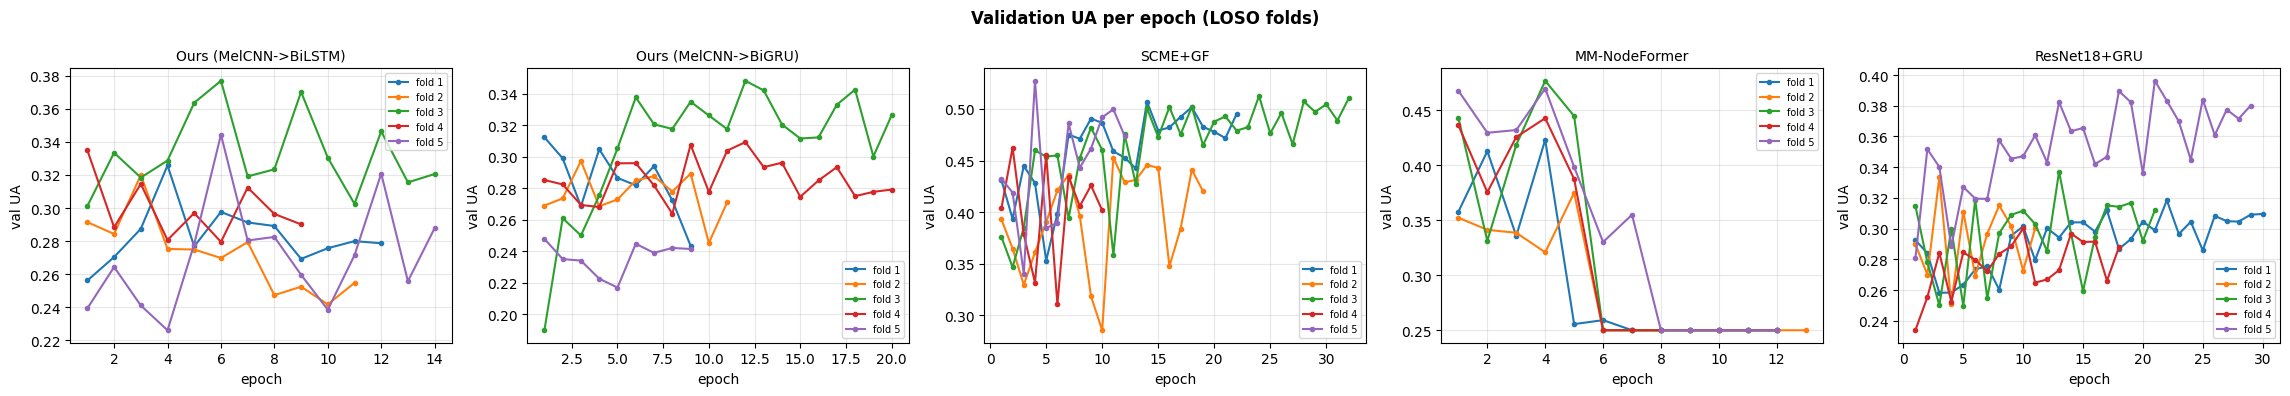

saved -> /Users/kaparya/Desktop/Diploma/trained_models/iemocap_benchmark_4class/logs/training_curves.png


In [11]:
fig, axes = plt.subplots(1, len(MODEL_ZOO), figsize=(4.6 * len(MODEL_ZOO), 4))
for ax, name in zip(np.atleast_1d(axes), MODEL_ZOO):
    mdir = RESULTS_DIR / slug(name)
    for k in range(1, 6):
        fp = mdir / f"fold_{k}.json"
        if not fp.exists():
            continue
        h = json.load(open(fp))["history"]
        ax.plot([e["epoch"] for e in h], [e["val_ua"] for e in h],
                marker="o", ms=3, label=f"fold {k}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("epoch"); ax.set_ylabel("val UA"); ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.suptitle("Validation UA per epoch (LOSO folds)", fontweight="bold")
plt.tight_layout()
plt.savefig(LOG_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved ->", LOG_DIR / "training_curves.png")

## 10. Stage 10 — Final benchmark table & confusion matrices

`Model · Params · Modalities · WA · UA · Macro-F1`, mean ± std over the 5 folds.
Saved to `results/benchmark_table.csv`; aggregated per-model confusion matrices
to `results/confusion_matrices.png`.

=== IEMOCAP 4-class · LOSO 5-fold benchmark ===
                Model Params  Modalities               WA         UA (UAR)         Macro F1
              SCME+GF  0.97M audio+video 0.4127 +- 0.0312 0.4626 +- 0.0294 0.3814 +- 0.0203
        MM-NodeFormer  1.49M audio+video 0.3862 +- 0.0520 0.4260 +- 0.0456 0.3516 +- 0.0511
         ResNet18+GRU  0.81M       video 0.3192 +- 0.0480 0.3110 +- 0.0450 0.2782 +- 0.0498
Ours (MelCNN->BiLSTM)  3.58M audio+video 0.2909 +- 0.0477 0.2849 +- 0.0233 0.2391 +- 0.0282
 Ours (MelCNN->BiGRU)  2.19M audio+video 0.3122 +- 0.0415 0.2735 +- 0.0236 0.2475 +- 0.0082

Per-class F1 (mean over folds):
                Model neutral F1 happy F1 sad F1 angry F1
Ours (MelCNN->BiLSTM)      0.298    0.200  0.305    0.154
 Ours (MelCNN->BiGRU)      0.412    0.241  0.133    0.204
              SCME+GF      0.085    0.447  0.536    0.458
        MM-NodeFormer      0.193    0.283  0.493    0.437
         ResNet18+GRU      0.340    0.277  0.297    0.199


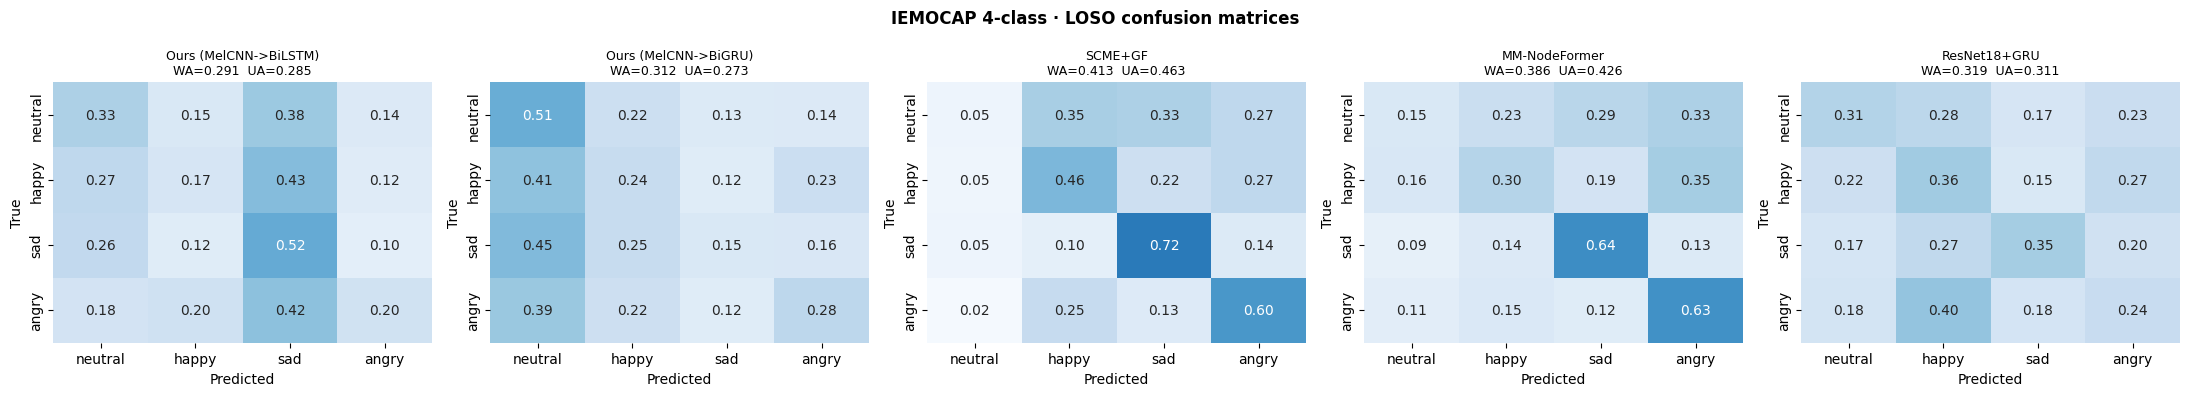


saved -> results/benchmark_table.csv, results/confusion_matrices.png


In [12]:
rows, summaries = [], {}
for name in MODEL_ZOO:
    sp = RESULTS_DIR / slug(name) / "summary.json"
    if not sp.exists():
        continue
    s = json.load(open(sp)); summaries[name] = s
    fmt = lambda v: f"{v[0]:.4f} +- {v[1]:.4f}"
    rows.append({"Model": name,
                 "Params": f"{s['n_params']/1e6:.2f}M",
                 "Modalities": s["modalities"],
                 "WA": fmt(s["wa"]), "UA (UAR)": fmt(s["ua"]),
                 "Macro F1": fmt(s["macro_f1"]),
                 "_ua": s["ua"][0]})
table = (pd.DataFrame(rows).sort_values("_ua", ascending=False)
           .drop(columns="_ua").reset_index(drop=True))
print("=== IEMOCAP 4-class · LOSO 5-fold benchmark ===")
print(table.to_string(index=False))
table.to_csv(RESULTS_DIR / "benchmark_table.csv", index=False)

# --- per-class F1 table ------------------------------------------------
pc_rows = []
for name, s in summaries.items():
    row = {"Model": name}
    row.update({f"{LABELS_4[c]} F1": f"{s['f1_per_class_mean'][c]:.3f}"
                for c in range(N_CLS)})
    pc_rows.append(row)
print("\nPer-class F1 (mean over folds):")
print(pd.DataFrame(pc_rows).to_string(index=False))

# --- aggregated confusion matrices ------------------------------------
n = len(summaries)
fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 4))
for ax, name in zip(np.atleast_1d(axes), summaries):
    mdir = RESULTS_DIR / slug(name)
    cm = np.zeros((N_CLS, N_CLS))
    for k in range(1, 6):
        fp = mdir / f"fold_{k}.json"
        if fp.exists():
            cm += np.array(json.load(open(fp))["confusion"])
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LABELS_4, yticklabels=LABELS_4, cbar=False, ax=ax)
    s = summaries[name]
    ax.set_title(f"{name}\nWA={s['wa'][0]:.3f}  UA={s['ua'][0]:.3f}", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("IEMOCAP 4-class · LOSO confusion matrices", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nsaved -> results/benchmark_table.csv, results/confusion_matrices.png")

## Reproducibility log & README

Records the git hash, config, device and package versions to
`trained_models/iemocap_benchmark_4class/run_meta.json`, and writes
`results/README.md` with full reproduction instructions.

In [13]:
run_meta = dict(
    git_hash=git_hash(), seed=SEED, device=str(device),
    timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
    n_utterances=int(len(meta)), classes=LABELS_4,
    sessions=SESSIONS, loso_val_for_test=LOSO_VAL_FOR_TEST,
    train_cfg=TRAIN_CFG,
    versions=dict(python=platform.python_version(),
                  torch=torch.__version__, numpy=np.__version__,
                  pandas=pd.__version__),
)
json.dump(run_meta, open(OUT_DIR / "run_meta.json", "w"), indent=2)

readme = f"""# IEMOCAP MER Benchmark — 4-class, LOSO 5-fold

Audio + facial-expression emotion recognition benchmark on IEMOCAP, produced by
`notebooks/iemocap_benchmark_4class.ipynb`.

## Protocol
- **Classes:** neutral, happy (incl. excited), sad, angry.
- **Split:** Leave-One-Session-Out 5-fold; metrics are mean +- std over folds.
- **Metrics:** WA, UA/UAR (main), Macro-F1, per-class F1, confusion matrix.
- **Face selection:** gender-letter heuristic (speaker letter in the utterance
  id picks the half-frame); MediaPipe BlazeFace crop.

## Reproduce
1. `source venv/bin/activate && jupyter notebook`
2. Open `notebooks/iemocap_benchmark_4class.ipynb`, Run All. The first run
   builds the feature cache `datasets/iemocap_features_cache/` if missing
   (slow, one-time); later runs reuse it.
3. Outputs:
   - `metadata/iemocap_4class.csv` — dataset index
   - `results/<model>/fold_k.json`, `summary.json` — per-fold & aggregated metrics
   - `results/benchmark_table.csv` — final comparison table
   - `results/confusion_matrices.png`, `logs/training_curves.png`
   - `trained_models/iemocap_benchmark_4class/checkpoints/` — per-fold weights
   - `run_meta.json` — git hash, config, versions

Set `BENCH_QUICK=1` in the environment for a fast 2-epoch smoke run.
Reproducibility: fixed seeds, deterministic algorithms, git hash logged.
"""
open(RESULTS_DIR / "README.md", "w").write(readme)
print("saved -> run_meta.json, results/README.md")
print(json.dumps(run_meta, indent=2, default=str))

saved -> run_meta.json, results/README.md
{
  "git_hash": "fee2a24664e3717732eb186eaad32975b3a5d2b7",
  "seed": 42,
  "device": "mps",
  "timestamp": "2026-05-20 00:42:11",
  "n_utterances": 5531,
  "classes": [
    "neutral",
    "happy",
    "sad",
    "angry"
  ],
  "sessions": [
    "Session1",
    "Session2",
    "Session3",
    "Session4",
    "Session5"
  ],
  "loso_val_for_test": {
    "Session1": "Session2",
    "Session2": "Session3",
    "Session3": "Session4",
    "Session4": "Session5",
    "Session5": "Session1"
  },
  "train_cfg": {
    "epochs": 40,
    "patience": 8,
    "batch_size": 16,
    "lr": 0.001,
    "lr_finetune": 0.0003,
    "weight_decay": 0.0001,
    "label_smoothing": 0.1,
    "grad_clip": 1.0,
    "accum_steps": 1,
    "num_workers": 0,
    "augment": false,
    "aug_noise": 0.05
  },
  "versions": {
    "python": "3.12.7",
    "torch": "2.10.0",
    "numpy": "2.3.0",
    "pandas": "3.0.0"
  }
}
